# CPDO — Constant Proportion Debt Obligation
Design, simulation, and default probability estimation using CDX.NA.IG 5Y data.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (13, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## Section 1 — Data

In [3]:
# 1.1 — CDX.NA.IG 5Y spread data
cdx = pd.read_csv(
    'CDX IG CDSI GEN 5Y Corp(CDX IG CDSI GEN 5Y Corp).csv',
    sep=';'
)
cdx.columns = ['Date', 'Spread']
cdx['Date'] = pd.to_datetime(cdx['Date'])
cdx['Spread'] = cdx['Spread'].astype(str).str.replace(',', '.', regex=False).astype(float)
cdx = cdx.sort_values('Date').reset_index(drop=True).dropna()

date_min = cdx['Date'].min().date()
date_max = cdx['Date'].max().date()
print(f'CDX rows:   {len(cdx)}')
print(f'Date range: {date_min}  to  {date_max}')
cdx.head(3)

CDX rows:   3655
Date range: 2011-09-09  to  2026-04-23


,Date,Spread
0,2011-09-09,132.25
1,2011-09-12,135.75
2,2011-09-13,132.25


In [4]:
# 1.2 — SOFR daily rate
sofr = pd.read_csv('SOFR rates(Daily).csv', sep=';')
sofr.columns = ['Date', 'Rate']
sofr['Date'] = pd.to_datetime(sofr['Date'])
sofr['Rate'] = sofr['Rate'].astype(str).str.replace(',', '.', regex=False).astype(float) / 100
sofr = sofr.sort_values('Date').reset_index(drop=True).dropna()

date_min = sofr['Date'].min().date()
date_max = sofr['Date'].max().date()
print(f'SOFR rows:  {len(sofr)}')
print(f'Date range: {date_min}  to  {date_max}')
sofr.head(3)

SOFR rows:  5579
Date range: 2004-01-02  to  2026-04-21


,Date,Rate
0,2004-01-02,0.0336
1,2004-01-05,0.0339
2,2004-01-06,0.0326


In [6]:
# 1.3 — Validate
issues = []

dup_cdx    = cdx['Date'].duplicated().sum()
dup_sofr   = sofr['Date'].duplicated().sum()
nan_spread = cdx['Spread'].isna().sum()
nan_rate   = sofr['Rate'].isna().sum()
neg_spread = (cdx['Spread'] <= 0).sum()
max_gap    = cdx['Date'].diff().dt.days.dropna().max()

if dup_cdx:     issues.append(f'CDX: {dup_cdx} duplicate dates')
if dup_sofr:    issues.append(f'SOFR: {dup_sofr} duplicate dates')
if nan_spread:  issues.append(f'CDX: {nan_spread} missing spreads')
if nan_rate:    issues.append(f'SOFR: {nan_rate} missing rates')
if neg_spread:  issues.append(f'CDX: {neg_spread} non-positive spreads')
if max_gap > 5: issues.append(f'CDX: largest date gap = {int(max_gap)} calendar days')

if issues:
    print('Issues found:')
    for issue in issues:
        print(f'  {issue}')
else:
    s_min, s_max = cdx['Spread'].min(), cdx['Spread'].max()
    r_min = sofr['Rate'].min() * 100
    r_max = sofr['Rate'].max() * 100
    print('Both datasets clean: no duplicates, nulls, or non-positive values')
    print(f'CDX:  {len(cdx)} trading days | spread range: {s_min:.1f} to {s_max:.1f} bps')
    print(f'SOFR: {len(sofr)} days         | rate range:   {r_min:.2f}% to {r_max:.2f}%')

Both datasets clean: no duplicates, nulls, or non-positive values
CDX:  3655 trading days | spread range: 43.8 to 151.8 bps
SOFR: 5579 days         | rate range:   0.19% to 5.23%


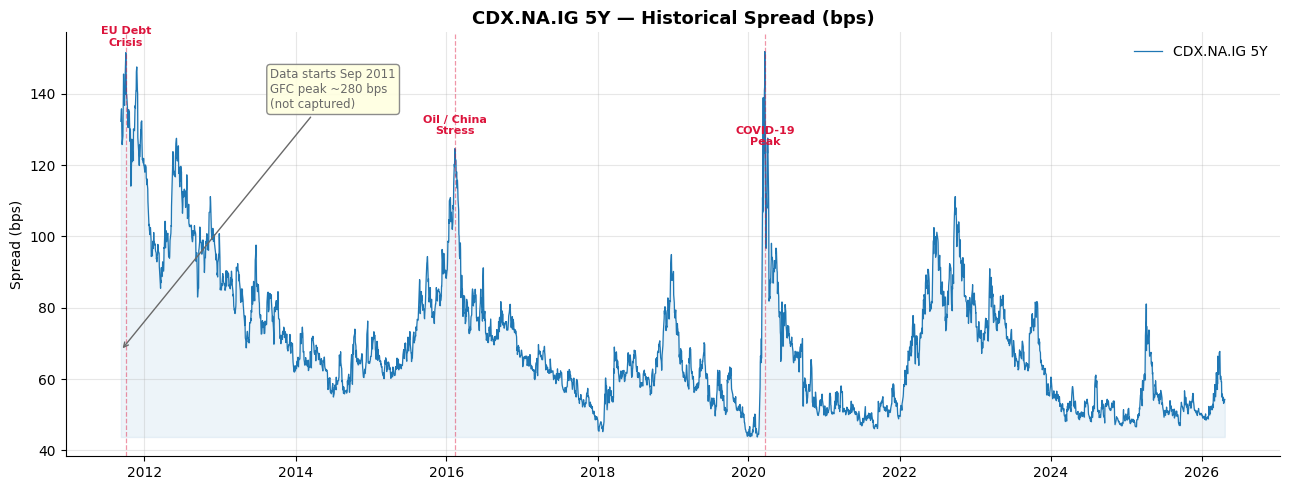

In [7]:
# 1.4 — CDX spread history
fig, ax = plt.subplots()
ax.plot(cdx['Date'], cdx['Spread'], color='#1f77b4', linewidth=0.9, label='CDX.NA.IG 5Y')
ax.fill_between(cdx['Date'], cdx['Spread'].min(), cdx['Spread'], alpha=0.08, color='#1f77b4')

events = [
    ('2011-10-04', 'EU Debt\nCrisis'),
    ('2016-02-11', 'Oil / China\nStress'),
    ('2020-03-23', 'COVID-19\nPeak'),
]
for date_str, label in events:
    d = pd.to_datetime(date_str)
    idx = (cdx['Date'] - d).abs().idxmin()
    y = cdx.loc[idx, 'Spread']
    ax.axvline(d, color='crimson', linestyle='--', alpha=0.45, linewidth=0.9)
    ax.text(d, y + 4, label, fontsize=8, ha='center', color='crimson', fontweight='bold')

msg = 'Data starts Sep 2011\nGFC peak ~280 bps\n(not captured)'
ax.annotate(
    msg,
    xy=(pd.to_datetime('2011-09-09'), 68),
    xytext=(pd.to_datetime('2013-09-01'), 136),
    fontsize=8.5, color='dimgray',
    arrowprops=dict(arrowstyle='->', color='dimgray', lw=1.0),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.9),
)

ax.set_title('CDX.NA.IG 5Y — Historical Spread (bps)', fontsize=13, fontweight='bold')
ax.set_ylabel('Spread (bps)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(frameon=False, loc='upper right')
plt.tight_layout()
plt.show()

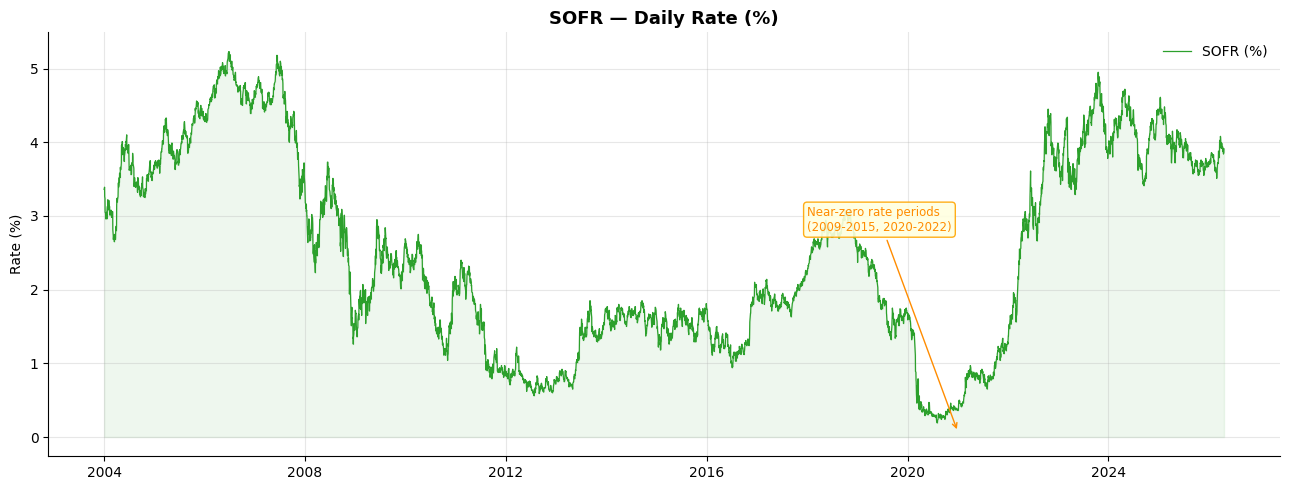

In [8]:
# 1.5 — SOFR rate history
fig, ax = plt.subplots()
ax.plot(sofr['Date'], sofr['Rate'] * 100, color='#2ca02c', linewidth=0.9, label='SOFR (%)')
ax.fill_between(sofr['Date'], 0, sofr['Rate'] * 100, alpha=0.08, color='#2ca02c')

msg = 'Near-zero rate periods\n(2009-2015, 2020-2022)'
ax.annotate(
    msg,
    xy=(pd.to_datetime('2021-01-01'), 0.07),
    xytext=(pd.to_datetime('2018-01-01'), 2.8),
    fontsize=8.5, color='darkorange',
    arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.0),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='orange', alpha=0.9),
)

ax.set_title('SOFR — Daily Rate (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Rate (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [9]:
# 1.6 — Summary statistics (SOFR restricted to CDX period)
sofr_overlap = sofr[sofr['Date'] >= cdx['Date'].min()].copy()

stats = pd.DataFrame({
    'CDX Spread (bps)': cdx['Spread'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]),
    'SOFR % [2011-2026]': (sofr_overlap['Rate'] * 100).describe(
        percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
    ),
}).round(3)

stats

,CDX Spread (bps),SOFR % [2011-2026]
count,3655.000,3653.000
mean,69.591,2.119
std,19.013,1.262
min,43.750,0.190
5%,48.875,0.410
25%,54.604,1.150
50%,65.059,1.710
75%,78.986,3.290
95%,108.125,4.310
max,151.798,4.950


### 1.7 — Data Limitations

- **Missing GFC (2007–2009):** Data starts Sep 2011. CDX.NA.IG peaked at ~280 bps during the crisis — nearly double our sample's maximum. The CIR model will be calibrated to a post-crisis regime, underestimating tail spread risk. Addressed via stress testing in Section 9.
- **SOFR proxy:** Pre-2018 values are a backward extension from Treasury repo rates. Treated as a consistent risk-free rate throughout.
- **Index only:** We model the CDX index as a single factor. No individual-name CDS data needed.

---
## Section 2 — CPDO Design
We design a 10-year CPDO: investors receive 3M SOFR + 150 bps quarterly; the vehicle sells CDX.NA.IG protection with dynamic leverage to fill the return gap.

In [10]:
from dataclasses import dataclass

@dataclass
class CPDOParams:
    # Capital structure
    initial_nav:     float = 100.0
    target_nav:      float = 150.0   # cash-out trigger
    floor_nav:       float = 10.0    # default trigger

    # Portfolio
    max_leverage:    float = 15.0
    n_names:         int   = 125     # CDX.NA.IG index composition
    risky_duration:  float = 4.5     # years; DV01 = risky_duration * 1e-4
    recovery_rate:   float = 0.40

    # Coupon and costs
    investor_spread: float = 0.0150  # SOFR + 150 bps, paid quarterly
    management_fee:  float = 0.0030  # 30 bps p.a.
    roll_cost_bps:   float = 2.0     # bps of exposure per 6-month roll
    roll_every:      int   = 126     # trading days (~6 months)

    # Simulation grid
    T:               float = 10.0
    dt:              float = 1 / 252

cpdo = CPDOParams()
dv01 = cpdo.risky_duration * 1e-4
lgd  = 1.0 - cpdo.recovery_rate

print(f'DV01:        {dv01:.5f}  per bp per $1 notional')
print(f'LGD:         {lgd:.0%}')
print(f'Total steps: {int(cpdo.T / cpdo.dt)} ({int(cpdo.T)} years at dt = 1/252)')

DV01:        0.00045  per bp per $1 notional
LGD:         60%
Total steps: 2520 (10 years at dt = 1/252)


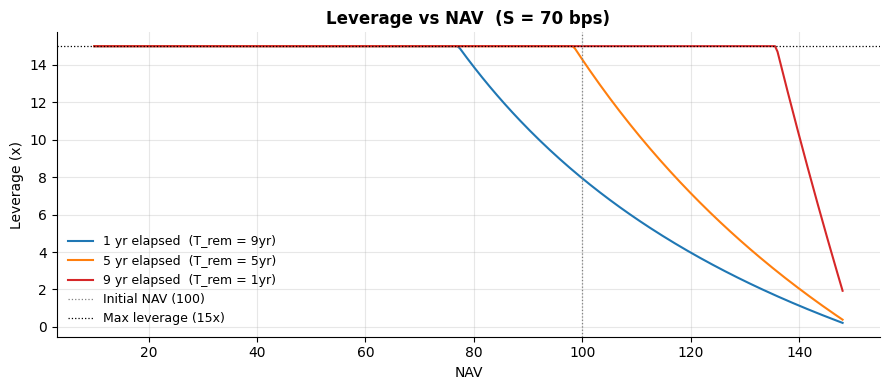

In [11]:
def compute_leverage(nav, S, step, cpdo):
    # L = shortfall / (nav * carry_rate * T_remaining)
    # Sets exposure so carry income fills the gap to target_nav over remaining tenor
    T_remaining = np.maximum(cpdo.T - step * cpdo.dt, cpdo.dt)
    shortfall   = np.maximum(cpdo.target_nav - nav, 0.0)
    carry_rate  = np.maximum(S / 10_000, 1e-9)
    nav_safe    = np.maximum(nav, 1e-9)
    L = shortfall / (nav_safe * carry_rate * T_remaining)
    return np.clip(L, 0.0, cpdo.max_leverage)

# Leverage vs NAV at three points in the CPDO's life (S = 70 bps)
nav_range = np.linspace(10, 148, 300)
S_demo    = 70

fig, ax = plt.subplots(figsize=(9, 4))
for step, label, color in [
    (int(cpdo.T * 0.10 * 252), '1 yr elapsed  (T_rem = 9yr)', '#1f77b4'),
    (int(cpdo.T * 0.50 * 252), '5 yr elapsed  (T_rem = 5yr)', '#ff7f0e'),
    (int(cpdo.T * 0.90 * 252), '9 yr elapsed  (T_rem = 1yr)', '#d62728'),
]:
    ax.plot(nav_range, compute_leverage(nav_range, S_demo, step, cpdo),
            color=color, linewidth=1.5, label=label)

ax.axvline(cpdo.initial_nav, color='gray', linestyle=':', linewidth=0.9, label='Initial NAV (100)')
ax.axhline(cpdo.max_leverage, color='black', linestyle=':', linewidth=0.9,
           label=f'Max leverage ({cpdo.max_leverage:.0f}x)')
ax.set_xlabel('NAV')
ax.set_ylabel('Leverage (x)')
ax.set_title(f'Leverage vs NAV  (S = {S_demo} bps)', fontsize=12, fontweight='bold')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
# Cash flow components — one illustrative daily step
# NAV = 100, S = 70 bps, SOFR = 4%, at year 1
_nav  = 100.0
_S    = 70.0
_sofr = 0.04
_L    = compute_leverage(_nav, _S, 252, cpdo)
_exp  = _L * _nav

print(f'Leverage = {_L:.2f}x   |   Exposure = {_exp:.1f}')
print()
h1, h2, h3 = 'Component', 'Daily', 'Annual est.'
print(f'{h1:<37}  {h2:>8}  {h3:>11}')
print('-' * 61)

rows = [
    ('(+) Carry income',             +_exp * (_S / 10_000) * cpdo.dt),
    ('(+) Interest on collateral',    +_sofr * _nav * cpdo.dt),
    ('(-) Investor coupon',           -(_sofr + cpdo.investor_spread) * _nav * cpdo.dt),
    ('(-) Management fee',            -cpdo.management_fee * _nav * cpdo.dt),
    ('(-) MTM per 1 bp widening',     -_exp * dv01),
    ('(-) Default loss per name',     -_exp * lgd / cpdo.n_names),
]
for name, val in rows:
    is_event = 'bp widening' in name or 'per name' in name
    ann = f'{val * 252:+.3f}' if not is_event else '   (event)'
    print(f'{name:<37}  {val:>+8.4f}  {ann:>11}')

print()
net_carry = sum(v for n, v in rows if 'MTM' not in n and 'Default' not in n)
print(f'Net daily carry (excl. MTM & defaults): {net_carry:+.4f}  ({net_carry*252:+.3f} p.a.)')
print(f'Days of carry wiped by 1 bp widening:   {abs(-_exp * dv01) / net_carry:.0f} days')

Leverage = 7.94x   |   Exposure = 793.7

Component                                 Daily  Annual est.
-------------------------------------------------------------
(+) Carry income                        +0.0220       +5.556
(+) Interest on collateral              +0.0159       +4.000
(-) Investor coupon                     -0.0218       -5.500
(-) Management fee                      -0.0012       -0.300
(-) MTM per 1 bp widening               -0.3571      (event)
(-) Default loss per name               -3.8095      (event)

Net daily carry (excl. MTM & defaults): +0.0149  (+3.756 p.a.)
Days of carry wiped by 1 bp widening:   24 days


### The Leverage Feedback Loop

Spread widening hits the CPDO on two fronts simultaneously: **MTM losses** reduce NAV, and lower NAV forces **higher leverage** (larger shortfall → formula demands more exposure). More exposure then amplifies the next spread move.

This spiral — *widen → lose → lever up → lose more* — is the primary default driver. Individual name defaults cause small, bounded losses (~0.5% of exposure each); it is sustained spread stress that kills CPDOs.

---
## Section 3 — CIR Spread Model
Model: `dS = κ(θ − S) dt + σ√S dW`. Calibrated by OLS on daily increments using the CIR-consistent sigma estimator.

In [13]:
@dataclass
class CIRParams:
    kappa: float
    theta: float
    sigma: float
    s0:    float

def calibrate_cir(spreads, dt=1/252):
    s_t  = spreads[:-1]
    ds   = spreads[1:] - spreads[:-1]

    X           = np.vstack([np.ones_like(s_t), s_t]).T
    alpha, beta = np.linalg.lstsq(X, ds, rcond=None)[0]

    kappa = max(-beta / dt, 0.01)
    theta = max(alpha / (kappa * dt), 1.0)

    residuals = ds - (alpha + beta * s_t)
    # CIR-consistent: Var(dS) = sigma^2 * S_t * dt  =>  sigma = sqrt(mean(resid^2 / (S_t * dt)))
    sigma = np.sqrt(np.mean(residuals**2 / (np.maximum(s_t, 1e-6) * dt)))

    return CIRParams(kappa=kappa, theta=theta, sigma=sigma, s0=spreads[-1])

spreads = cdx['Spread'].values
cir = calibrate_cir(spreads)

print(f'kappa  (mean-reversion speed): {cir.kappa:.4f}')
print(f'theta  (long-term mean):       {cir.theta:.4f} bps  (sample mean: {spreads.mean():.2f})')
print(f'sigma  (CIR-correct):          {cir.sigma:.4f}')
print(f's0     (current spread):       {cir.s0:.4f} bps')
print()
print(f'Half-life of mean reversion:   {np.log(2)/cir.kappa:.2f} yr  ({np.log(2)/cir.kappa*252:.0f} trading days)')
print()
assert cir.kappa > 0 and cir.theta > 0 and cir.sigma > 0, 'parameter sign check failed'
print('Sanity checks passed')

kappa  (mean-reversion speed): 2.2759
theta  (long-term mean):       67.2328 bps  (sample mean: 69.59)
sigma  (CIR-correct):          4.0620
s0     (current spread):       54.2880 bps

Half-life of mean reversion:   0.30 yr  (77 trading days)

Sanity checks passed


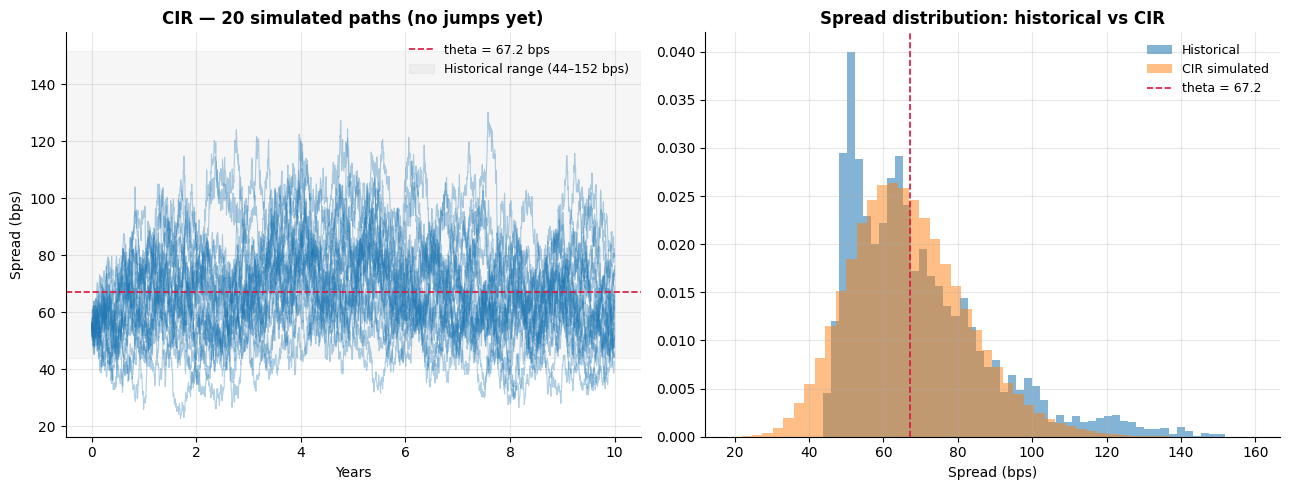

Simulated:  mean=66.79  std=15.62
Historical: mean=69.59  std=19.01
CIR std is lighter than historical (15.62 vs 19.01) — jump component needed (Section 4)


In [14]:
def simulate_cir_paths(cir, n_paths, T, dt=1/252, seed=42):
    # Pure CIR — Euler-Maruyama (no jumps; jump component added in Section 4)
    n_steps  = int(T / dt)
    rng      = np.random.default_rng(seed)
    paths    = np.zeros((n_steps + 1, n_paths))
    paths[0] = cir.s0
    for t in range(n_steps):
        S          = np.maximum(paths[t], 1e-6)
        dW         = rng.standard_normal(n_paths) * np.sqrt(dt)
        dS         = cir.kappa * (cir.theta - S) * dt + cir.sigma * np.sqrt(S) * dW
        paths[t+1] = np.maximum(S + dS, 1e-6)
    return paths

paths_vis  = simulate_cir_paths(cir, n_paths=20,  T=cpdo.T, seed=42)
paths_dist = simulate_cir_paths(cir, n_paths=500, T=cpdo.T, seed=99)

t_axis   = np.linspace(0, cpdo.T, paths_vis.shape[0])
hist_min = cdx['Spread'].min()
hist_max = cdx['Spread'].max()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — simulated paths
ax = axes[0]
ax.plot(t_axis, paths_vis, color='#1f77b4', alpha=0.35, linewidth=0.8)
ax.axhline(cir.theta, color='crimson', linestyle='--', linewidth=1.2,
           label=f'theta = {cir.theta:.1f} bps')
ax.axhspan(hist_min, hist_max, alpha=0.07, color='gray',
           label=f'Historical range ({hist_min:.0f}–{hist_max:.0f} bps)')
ax.set_xlabel('Years')
ax.set_ylabel('Spread (bps)')
ax.set_title('CIR — 20 simulated paths (no jumps yet)', fontweight='bold')
ax.legend(frameon=False, fontsize=9)

# Right — spread distribution: simulated vs historical
ax = axes[1]
sim_vals = paths_dist[1:].flatten()
ax.hist(cdx['Spread'], bins=50, alpha=0.55, color='#1f77b4', density=True, label='Historical')
ax.hist(sim_vals,      bins=50, alpha=0.50, color='#ff7f0e', density=True, label='CIR simulated')
ax.axvline(cir.theta, color='crimson', linestyle='--', linewidth=1.2,
           label=f'theta = {cir.theta:.1f}')
ax.set_xlabel('Spread (bps)')
ax.set_title('Spread distribution: historical vs CIR', fontweight='bold')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

print(f'Simulated:  mean={sim_vals.mean():.2f}  std={sim_vals.std():.2f}')
print(f'Historical: mean={spreads.mean():.2f}  std={spreads.std():.2f}')
print(f'CIR std is lighter than historical ({sim_vals.std():.2f} vs {spreads.std():.2f}) — jump component needed (Section 4)')

---
## Section 4 — Jump Component
Pure CIR is too smooth (std 15.7 vs historical 19.0). We overlay state-dependent jumps drawn from the empirical distribution of large moves to recover the fat-tailed behaviour.

In [15]:
@dataclass(eq=False)
class JumpParams:
    jump_sizes:       np.ndarray  # signed empirical large moves (bps)
    p_high:           float       # jump probability in high-spread regime
    p_low:            float       # jump probability in low-spread regime
    spread_threshold: float       # regime boundary (80th pct of historical spread)

def calibrate_jumps(spreads, pct_threshold=85, pct_regime=80):
    s_t    = spreads[:-1]
    ds     = spreads[1:] - spreads[:-1]
    abs_dS = np.abs(ds)

    # Identify large moves in either direction (fat-tail events)
    threshold  = np.percentile(abs_dS, pct_threshold)
    crisis     = abs_dS >= threshold
    jump_sizes = ds[crisis]       # signed: captures both widening and tightening

    # State-dependent probability: high-spread regime is more jump-prone
    spread_threshold = np.percentile(s_t, pct_regime)
    high_regime      = s_t > spread_threshold

    p_high = min(crisis[high_regime].mean(),  0.10)
    p_low  = min(crisis[~high_regime].mean(), 0.05)

    return JumpParams(jump_sizes=jump_sizes, p_high=p_high,
                      p_low=p_low, spread_threshold=spread_threshold)

jump = calibrate_jumps(spreads)

print(f'Crisis threshold (|dS| pct-85):  {np.percentile(np.abs(spreads[1:]-spreads[:-1]), 85):.4f} bps')
print(f'Crisis events:                   {len(jump.jump_sizes)} ({len(jump.jump_sizes)/len(spreads)*100:.1f}% of days)')
print(f'Jump mean:                        {jump.jump_sizes.mean():.4f} bps')
print(f'Jump std:                         {jump.jump_sizes.std():.4f} bps')
print(f'Jump range:                       {jump.jump_sizes.min():.2f} to {jump.jump_sizes.max():.2f} bps')
print()
print(f'Regime threshold (spread pct-80): {jump.spread_threshold:.2f} bps')
print(f'p_high (spread > threshold):      {jump.p_high:.4f}')
print(f'p_low  (spread <= threshold):     {jump.p_low:.4f}')

Crisis threshold (|dS| pct-85):  2.5151 bps
Crisis events:                   548 (15.0% of days)
Jump mean:                        0.1781 bps
Jump std:                         5.4176 bps
Jump range:                       -31.39 to 27.78 bps

Regime threshold (spread pct-80): 82.71 bps
p_high (spread > threshold):      0.1000
p_low  (spread <= threshold):     0.0500


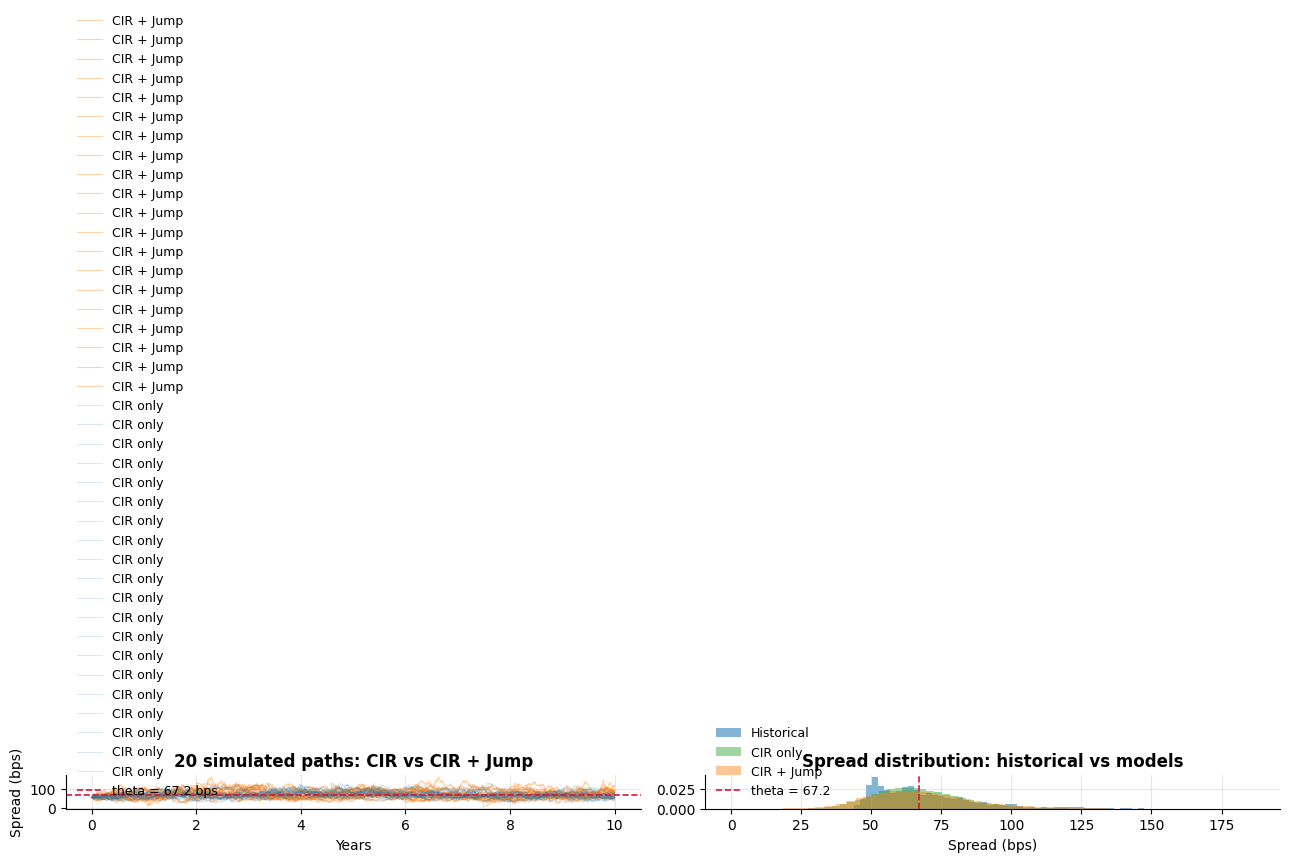

Historical:   mean=69.59  std=19.01
CIR only:     mean=66.79  std=15.62
CIR + Jump:   mean=67.68  std=18.66


In [16]:
def simulate_spread_paths(cir, jump, n_paths, T, dt=1/252, seed=42):
    # CIR diffusion + state-dependent empirical jumps
    n_steps  = int(T / dt)
    rng      = np.random.default_rng(seed)
    paths    = np.zeros((n_steps + 1, n_paths))
    paths[0] = cir.s0

    for t in range(n_steps):
        S    = np.maximum(paths[t], 1e-6)
        dW   = rng.standard_normal(n_paths) * np.sqrt(dt)
        dS   = cir.kappa * (cir.theta - S) * dt + cir.sigma * np.sqrt(S) * dW

        p_j   = np.where(S > jump.spread_threshold, jump.p_high, jump.p_low)
        fires = rng.random(n_paths) < p_j
        dS   += fires * rng.choice(jump.jump_sizes, size=n_paths)

        paths[t+1] = np.clip(S + dS, 1e-6, 2000)

    return paths

# --- Comparison: CIR only vs CIR + jumps ---
paths_cir  = simulate_cir_paths(cir,        n_paths=20,  T=cpdo.T, seed=42)
paths_jump = simulate_spread_paths(cir, jump, n_paths=20,  T=cpdo.T, seed=42)
dist_cir   = simulate_cir_paths(cir,        n_paths=500, T=cpdo.T, seed=99)
dist_jump  = simulate_spread_paths(cir, jump, n_paths=500, T=cpdo.T, seed=99)

t_axis = np.linspace(0, cpdo.T, paths_cir.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — 20 CIR+Jump paths
ax = axes[0]
ax.plot(t_axis, paths_jump, color='#ff7f0e', alpha=0.35, linewidth=0.8, label='CIR + Jump')
ax.plot(t_axis, paths_cir,  color='#1f77b4', alpha=0.20, linewidth=0.6, label='CIR only')
ax.axhline(cir.theta, color='crimson', linestyle='--', linewidth=1.2,
           label=f'theta = {cir.theta:.1f} bps')
ax.set_xlabel('Years')
ax.set_ylabel('Spread (bps)')
ax.set_title('20 simulated paths: CIR vs CIR + Jump', fontweight='bold')
ax.legend(frameon=False, fontsize=9)

# Right — three-way distribution comparison
ax = axes[1]
ax.hist(spreads,                  bins=50, alpha=0.55, color='#1f77b4', density=True, label='Historical')
ax.hist(dist_cir[1:].flatten(),   bins=50, alpha=0.45, color='#2ca02c', density=True, label='CIR only')
ax.hist(dist_jump[1:].flatten(),  bins=50, alpha=0.45, color='#ff7f0e', density=True, label='CIR + Jump')
ax.axvline(cir.theta, color='crimson', linestyle='--', linewidth=1.2,
           label=f'theta = {cir.theta:.1f}')
ax.set_xlabel('Spread (bps)')
ax.set_title('Spread distribution: historical vs models', fontweight='bold')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

# Summary
v_cir  = dist_cir[1:].flatten()
v_jump = dist_jump[1:].flatten()
print(f'Historical:   mean={spreads.mean():.2f}  std={spreads.std():.2f}')
print(f'CIR only:     mean={v_cir.mean():.2f}  std={v_cir.std():.2f}')
print(f'CIR + Jump:   mean={v_jump.mean():.2f}  std={v_jump.std():.2f}')

---
## Section 5 — Default Loss Model
Each CDX name that defaults costs `(1/N) × exposure × LGD`. Default intensity is risk-neutral: `λ = S / (10000 × LGD × risky_duration)`, so expected default losses equal the carry income — the CPDO's profit comes from the spread risk premium above physical losses.

In [17]:
def compute_default_loss(exposure, S, rng, n_paths, cpdo):
    # Risk-neutral intensity: spread ≈ lambda × LGD × risky_duration
    lambda_rn  = S / (10_000 * lgd * cpdo.risky_duration)   # per name per year
    lambda_agg = cpdo.n_names * lambda_rn * cpdo.dt          # aggregate per step
    n_def      = rng.poisson(lambda_agg, size=n_paths)
    return n_def * (1.0 / cpdo.n_names) * exposure * lgd

# Sanity check at year-1 representative values (L≈8x, NAV=100, S=70bps)
_L   = compute_leverage(100.0, 70.0, 252, cpdo)
_exp = _L * 100.0
_S   = 70.0

lambda_rn       = _S / (10_000 * lgd * cpdo.risky_duration)
per_name_loss   = (1 / cpdo.n_names) * _exp * lgd
ann_default_loss = cpdo.n_names * lambda_rn * per_name_loss
ann_carry        = _exp * _S / 10_000

print(f'lambda_rn (per name per year):        {lambda_rn:.5f}  ({lambda_rn*100:.3f}%)')
print(f'Per-name default loss:                {per_name_loss:.4f}  ({per_name_loss/_exp*100:.3f}% of exposure)')
print(f'Expected annual default loss:         {ann_default_loss:.4f}')
print(f'Annual carry income:                  {ann_carry:.4f}')
print(f'Default loss / carry:                 {ann_default_loss/ann_carry:.1%}  (risk-neutral break-even)')
print(f'=> MTM loss per 1bp widening:         {_exp * cpdo.risky_duration * 1e-4:.4f}  ({_exp * cpdo.risky_duration * 1e-4 / ann_carry * 252:.1f} days of carry)')

lambda_rn (per name per year):        0.00259  (0.259%)
Per-name default loss:                3.8095  (0.480% of exposure)
Expected annual default loss:         1.2346
Annual carry income:                  5.5556
Default loss / carry:                 22.2%  (risk-neutral break-even)
=> MTM loss per 1bp widening:         0.3571  (16.2 days of carry)


---
## Section 6 — Monte Carlo Simulation (Base Case)
10,000 paths over 10 years with all cash flow components. Spread paths generated by the CIR+Jump model from Sections 3–4; SOFR held at its last observed value.

In [25]:
# SOFR fixed at last observed value (SOFR cancels in carry-coupon net; only investor_spread matters)
sofr_rate = sofr['Rate'].mean()
print(f'SOFR rate used: {sofr_rate*100:.3f}%')

def run_cpdo_simulation(cir, jump, cpdo, sofr_rate, n_paths=10_000, seed=123,
                        s0_override=None, shock_bps=0.0, shock_year=None):
    dt      = cpdo.dt
    n_steps = int(cpdo.T / dt)
    rng     = np.random.default_rng(seed)

    # Allow s0 override for stress scenarios (Scenario A)
    cir_eff = CIRParams(kappa=cir.kappa, theta=cir.theta, sigma=cir.sigma,
                        s0=s0_override if s0_override is not None else cir.s0)
    spread_paths = simulate_spread_paths(cir_eff, jump, n_paths, cpdo.T, dt=dt, seed=seed + 1)

    # Apply optional mid-life spread shock (Scenario B)
    if shock_bps > 0 and shock_year is not None:
        shock_step = int(shock_year / dt)
        spread_paths[shock_step:] = np.clip(spread_paths[shock_step:] + shock_bps, 1e-6, 2000)

    nav        = np.full(n_paths, cpdo.initial_nav, dtype=float)
    active     = np.ones(n_paths, dtype=bool)
    defaulted  = np.zeros(n_paths, dtype=bool)
    cashed_out = np.zeros(n_paths, dtype=bool)
    event_step = np.full(n_paths, n_steps, dtype=int)
    coupon_acc = 0.0

    for t in range(n_steps):
        if not active.any():
            break

        S   = spread_paths[t]
        dS  = spread_paths[t + 1] - spread_paths[t]
        L   = compute_leverage(nav, S, t, cpdo)
        exp = L * nav

        carry     = exp * (S / 10_000) * dt
        interest  = sofr_rate * nav * dt
        mtm       = -exp * cpdo.risky_duration * 1e-4 * dS
        def_loss  = compute_default_loss(exp, S, rng, n_paths, cpdo)
        fee       = cpdo.management_fee * nav * dt
        roll      = (cpdo.roll_cost_bps * 1e-4 * exp
                     if (t > 0 and t % cpdo.roll_every == 0) else 0.0)

        coupon_acc += (sofr_rate + cpdo.investor_spread) * cpdo.initial_nav * dt
        coupon_pay  = coupon_acc if (t + 1) % 63 == 0 else 0.0
        if (t + 1) % 63 == 0:
            coupon_acc = 0.0

        delta_nav = carry + interest + mtm - def_loss - fee - roll - coupon_pay
        nav       = np.where(active, nav + delta_nav, nav)

        hit_floor  = active & (nav <= cpdo.floor_nav)
        hit_target = active & (nav >= cpdo.target_nav)
        hit        = hit_floor | hit_target

        event_step  = np.where(hit, t, event_step)
        defaulted  |= hit_floor
        cashed_out |= hit_target
        nav         = np.where(hit_floor,  cpdo.floor_nav,  nav)
        nav         = np.where(hit_target, cpdo.target_nav, nav)
        active     &= ~hit

    return dict(
        final_nav  = nav,
        defaulted  = defaulted,
        cashed_out = cashed_out,
        event_year = event_step * dt,
    )

SOFR rate used: 2.501%


In [26]:
import time
t0  = time.time()
res = run_cpdo_simulation(cir, jump, cpdo, sofr_rate, n_paths=10_000, seed=123)
print(f'Runtime: {time.time()-t0:.1f}s\n')

n      = len(res['final_nav'])
pd_base   = res['defaulted'].mean()
co_rate   = res['cashed_out'].mean()
alive     = (~res['defaulted'] & ~res['cashed_out']).mean()

print(f'Outcome breakdown (n={n:,} paths)')
print(f'  Defaulted  (NAV ≤ {cpdo.floor_nav}):   {pd_base*100:.2f}%')
print(f'  Cashed out (NAV ≥ {cpdo.target_nav:.0f}):  {co_rate*100:.2f}%')
print(f'  Alive at maturity:        {alive*100:.2f}%')
print()
print(f'Final NAV:  mean={res["final_nav"].mean():.2f}  median={np.median(res["final_nav"]):.2f}  '
      f'min={res["final_nav"].min():.2f}')
print()
print(f'Note: PD ≈ 0% is expected — the CIR model is calibrated to calm 2011–2026 data.')
print(f'Min simulated NAV: {np.percentile(res["final_nav"], 0):.1f}  (GFC peak was ~280 bps).')
print(f'Section 9 stress tests with elevated s0 will produce non-trivial PD.')

Runtime: 0.9s

Outcome breakdown (n=10,000 paths)
  Defaulted  (NAV ≤ 10.0):   0.00%
  Cashed out (NAV ≥ 150):  35.48%
  Alive at maturity:        64.52%

Final NAV:  mean=119.29  median=117.08  min=40.11

Note: PD ≈ 0% is expected — the CIR model is calibrated to calm 2011–2026 data.
Min simulated NAV: 40.1  (GFC peak was ~280 bps).
Section 9 stress tests with elevated s0 will produce non-trivial PD.


---
## Section 7 — Results & Analysis (Base Case)

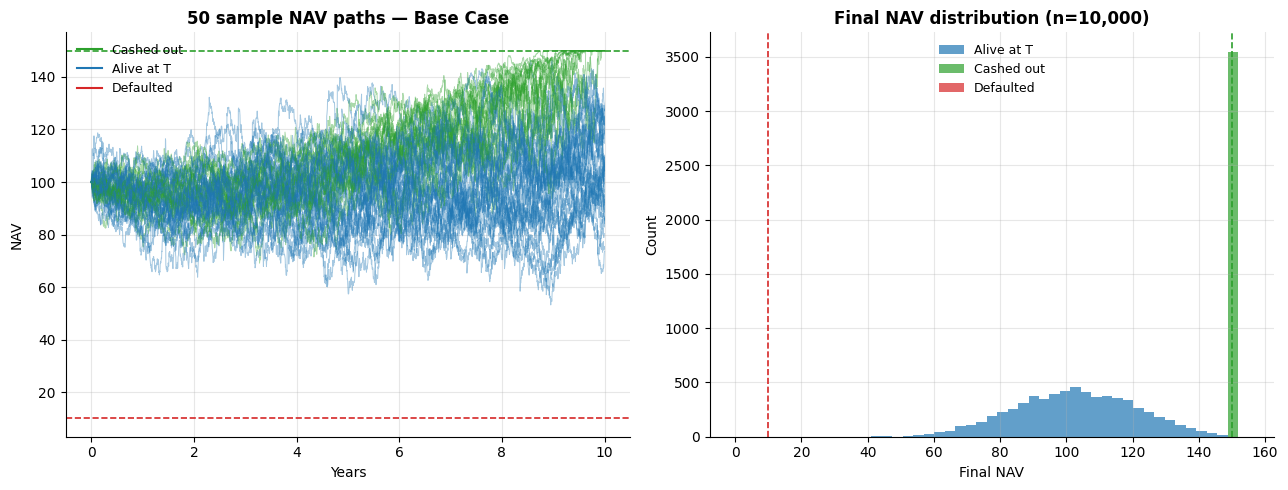

PD:         0.00%
Cash-out:   35.48%
Alive:      64.52%
Mean NAV:   119.29  |  Median: 117.08


In [27]:
# --- 50-path trajectory simulation for plotting ---
def record_cpdo_paths(cir, jump, cpdo, sofr_rate, n_paths=50, seed=42, s0_override=None,
                      shock_bps=0.0, shock_year=None):
    dt = cpdo.dt; n_steps = int(cpdo.T / dt)
    rng = np.random.default_rng(seed)
    cir_eff = CIRParams(kappa=cir.kappa, theta=cir.theta, sigma=cir.sigma,
                        s0=s0_override if s0_override is not None else cir.s0)
    spread_paths = simulate_spread_paths(cir_eff, jump, n_paths, cpdo.T, dt, seed+1)
    if shock_bps > 0 and shock_year is not None:
        shock_step = int(shock_year / dt)
        spread_paths[shock_step:] = np.clip(spread_paths[shock_step:] + shock_bps, 1e-6, 2000)

    nav = np.full(n_paths, cpdo.initial_nav, dtype=float)
    active = np.ones(n_paths, bool); defaulted = np.zeros(n_paths, bool)
    cashed_out = np.zeros(n_paths, bool)
    nav_hist = np.zeros((n_steps + 1, n_paths)); nav_hist[0] = nav
    coupon_acc = 0.0

    for t in range(n_steps):
        if not active.any(): break
        S = spread_paths[t]; dS = spread_paths[t+1] - spread_paths[t]
        L = compute_leverage(nav, S, t, cpdo); exp = L * nav
        delta = (exp*(S/10_000)*dt + sofr_rate*nav*dt
                 - exp*cpdo.risky_duration*1e-4*dS
                 - compute_default_loss(exp, S, rng, n_paths, cpdo)
                 - cpdo.management_fee*nav*dt
                 - (cpdo.roll_cost_bps*1e-4*exp if (t>0 and t%cpdo.roll_every==0) else 0.0))
        coupon_acc += (sofr_rate + cpdo.investor_spread) * cpdo.initial_nav * dt
        coupon_pay = coupon_acc if (t+1)%63==0 else 0.0
        if (t+1)%63==0: coupon_acc = 0.0
        nav = np.where(active, nav + delta - coupon_pay, nav)
        hit_floor = active & (nav <= cpdo.floor_nav)
        hit_target = active & (nav >= cpdo.target_nav)
        hit = hit_floor | hit_target
        defaulted |= hit_floor; cashed_out |= hit_target
        nav = np.where(hit_floor, cpdo.floor_nav, nav)
        nav = np.where(hit_target, cpdo.target_nav, nav)
        active &= ~hit
        nav_hist[t+1] = nav

    return nav_hist, defaulted, cashed_out

t_axis  = np.linspace(0, cpdo.T, int(cpdo.T / cpdo.dt) + 1)
nav_hist, def50, co50 = record_cpdo_paths(cir, jump, cpdo, sofr_rate, n_paths=50, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — NAV paths
ax = axes[0]
for i in range(50):
    color = '#2ca02c' if co50[i] else ('#d62728' if def50[i] else '#1f77b4')
    ax.plot(t_axis, nav_hist[:, i], color=color, alpha=0.4, linewidth=0.7)

ax.axhline(cpdo.target_nav, color='#2ca02c', linestyle='--', linewidth=1.2, label=f'Target NAV ({cpdo.target_nav})')
ax.axhline(cpdo.floor_nav,  color='#d62728', linestyle='--', linewidth=1.2, label=f'Floor NAV ({cpdo.floor_nav})')
ax.set_xlabel('Years'); ax.set_ylabel('NAV')
ax.set_title('50 sample NAV paths — Base Case', fontweight='bold')
from matplotlib.lines import Line2D
handles = [Line2D([0],[0],color='#2ca02c',lw=1.5,label='Cashed out'),
           Line2D([0],[0],color='#1f77b4',lw=1.5,label='Alive at T'),
           Line2D([0],[0],color='#d62728',lw=1.5,label='Defaulted')]
ax.legend(handles=handles, frameon=False, fontsize=9)

# Right — Final NAV distribution
ax = axes[1]
final = res['final_nav']
bins  = np.linspace(0, 155, 50)
alive_nav = final[(~res['defaulted']) & (~res['cashed_out'])]
ax.hist(alive_nav, bins=bins, color='#1f77b4', alpha=0.7, label='Alive at T')
ax.hist(final[res['cashed_out']],  bins=bins, color='#2ca02c', alpha=0.7, label='Cashed out')
ax.hist(final[res['defaulted']],   bins=bins, color='#d62728', alpha=0.7, label='Defaulted')
ax.axvline(cpdo.target_nav, color='#2ca02c', linestyle='--', linewidth=1.2)
ax.axvline(cpdo.floor_nav,  color='#d62728', linestyle='--', linewidth=1.2)
ax.set_xlabel('Final NAV'); ax.set_ylabel('Count')
ax.set_title('Final NAV distribution (n=10,000)', fontweight='bold')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout(); plt.show()

print(f'PD:         {res["defaulted"].mean()*100:.2f}%')
print(f'Cash-out:   {res["cashed_out"].mean()*100:.2f}%')
print(f'Alive:      {(~res["defaulted"]&~res["cashed_out"]).mean()*100:.2f}%')
print(f'Mean NAV:   {res["final_nav"].mean():.2f}  |  Median: {np.median(res["final_nav"]):.2f}')

---
## Section 9 — Stress Tests
**Scenario A:** CPDO issued into a crisis — `s0 = 200 bps` (GFC-era level), all other parameters unchanged.  
**Scenario B:** Crisis mid-life — +150 bps spread shock applied uniformly at year 3, CIR mean-reversion takes over from the elevated level.

Scenario A (0.8s):  PD=0.00%  Cash-out=96.67%  Mean NAV=148.84
Scenario B (1.0s):  PD=41.54%  Cash-out=2.98%  Mean NAV=42.78


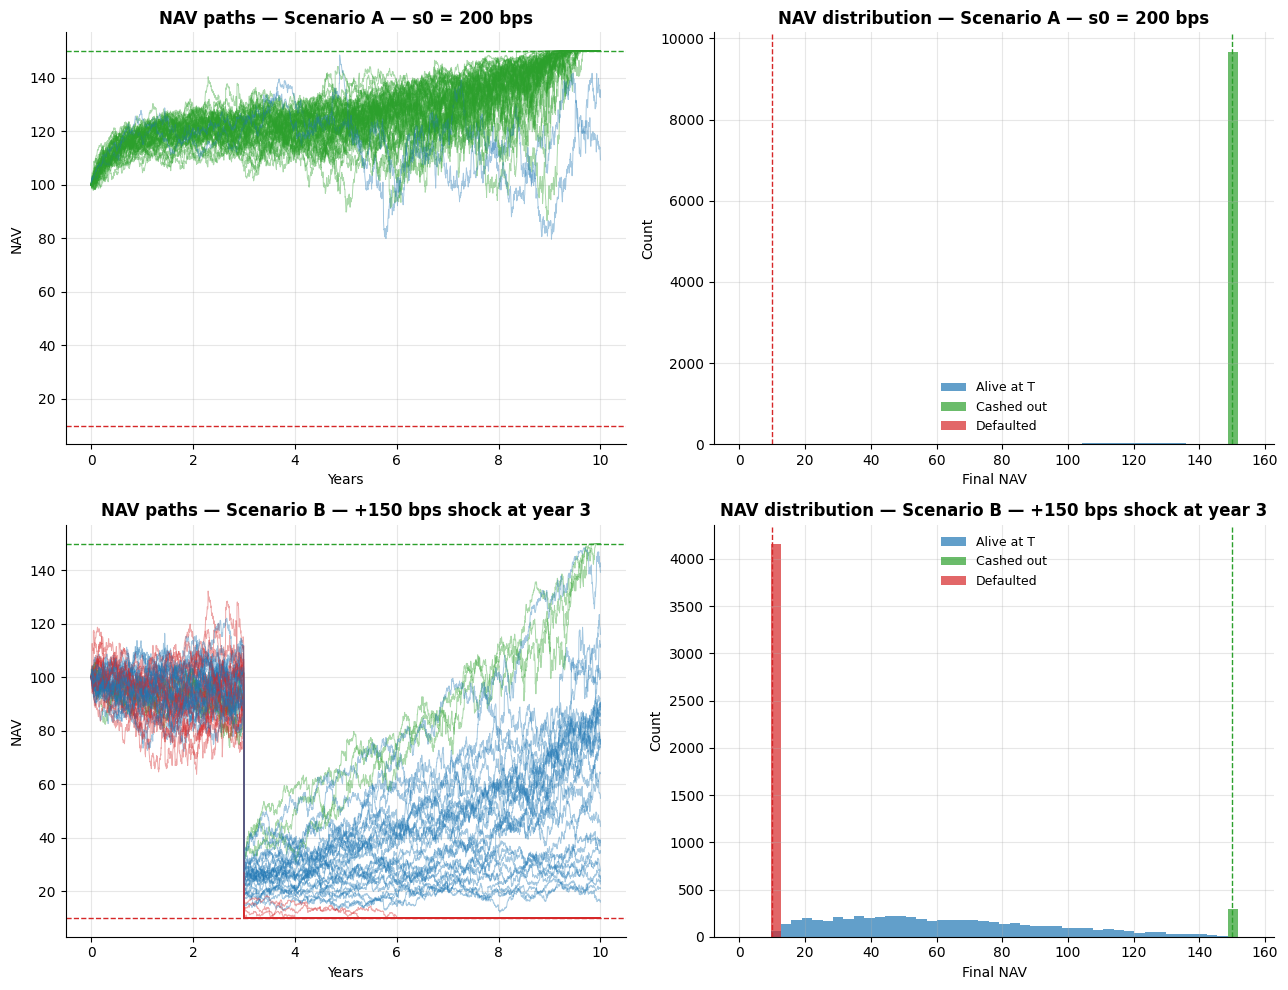

In [35]:
import time

# Scenario A — elevated starting spread (s0 = 200 bps)
t0    = time.time()
res_A = run_cpdo_simulation(cir, jump, cpdo, sofr_rate, n_paths=10_000, seed=456, s0_override=200.0)
print(f'Scenario A ({time.time()-t0:.1f}s):  PD={res_A["defaulted"].mean()*100:.2f}%  '
      f'Cash-out={res_A["cashed_out"].mean()*100:.2f}%  '
      f'Mean NAV={res_A["final_nav"].mean():.2f}')

# Scenario B — mid-life shock (+150 bps at year 3)
t0    = time.time()
res_B = run_cpdo_simulation(cir, jump, cpdo, sofr_rate, n_paths=10_000, seed=456,
                             shock_bps=150.0, shock_year=3.0)
print(f'Scenario B ({time.time()-t0:.1f}s):  PD={res_B["defaulted"].mean()*100:.2f}%  '
      f'Cash-out={res_B["cashed_out"].mean()*100:.2f}%  '
      f'Mean NAV={res_B["final_nav"].mean():.2f}')

# 50-path trajectories for stress scenarios
nav_A, def_A, co_A = record_cpdo_paths(cir, jump, cpdo, sofr_rate, n_paths=50, seed=42, s0_override=200.0)
nav_B, def_B, co_B = record_cpdo_paths(cir, jump, cpdo, sofr_rate, n_paths=50, seed=42,
                                        shock_bps=150.0, shock_year=3.0)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for row, (nav_traj, def_traj, co_traj, scenario) in enumerate([
    (nav_A, def_A, co_A, 'Scenario A — s0 = 200 bps'),
    (nav_B, def_B, co_B, 'Scenario B — +150 bps shock at year 3'),
]):
    # NAV paths
    ax = axes[row, 0]
    for i in range(50):
        color = '#2ca02c' if co_traj[i] else ('#d62728' if def_traj[i] else '#1f77b4')
        ax.plot(t_axis, nav_traj[:, i], color=color, alpha=0.4, linewidth=0.7)
    ax.axhline(cpdo.target_nav, color='#2ca02c', linestyle='--', linewidth=1.0)
    ax.axhline(cpdo.floor_nav,  color='#d62728', linestyle='--', linewidth=1.0)
    ax.set_xlabel('Years'); ax.set_ylabel('NAV')
    ax.set_title(f'NAV paths — {scenario}', fontweight='bold')

    # Final NAV distribution
    ax   = axes[row, 1]
    r    = res_A if row == 0 else res_B
    bins = np.linspace(0, 155, 50)
    ax.hist(r['final_nav'][~r['defaulted'] & ~r['cashed_out']],
            bins=bins, color='#1f77b4', alpha=0.7, label='Alive at T')
    ax.hist(r['final_nav'][r['cashed_out']],  bins=bins, color='#2ca02c', alpha=0.7, label='Cashed out')
    ax.hist(r['final_nav'][r['defaulted']],   bins=bins, color='#d62728', alpha=0.7, label='Defaulted')
    ax.axvline(cpdo.target_nav, color='#2ca02c', linestyle='--', linewidth=1.0)
    ax.axvline(cpdo.floor_nav,  color='#d62728', linestyle='--', linewidth=1.0)
    ax.set_xlabel('Final NAV'); ax.set_ylabel('Count')
    ax.set_title(f'NAV distribution — {scenario}', fontweight='bold')
    ax.legend(frameon=False, fontsize=9)

plt.tight_layout(); plt.show()

In [36]:
# Summary table
scenarios = {
    'Base (s0 = 54 bps)':            res,
    'Scenario A (s0 = 200 bps)':     res_A,
    'Scenario B (+150 bps at yr 3)': res_B,
}

print(f'{"Scenario":<35} {"PD":>8} {"Cash-out":>10} {"Alive":>8} {"Mean NAV":>10} {"Median NAV":>11}')
print('-' * 85)
for label, r in scenarios.items():
    pd_  = r['defaulted'].mean()
    co_  = r['cashed_out'].mean()
    al_  = 1 - pd_ - co_
    mn   = r['final_nav'].mean()
    med  = np.median(r['final_nav'])
    print(f'{label:<35} {pd_*100:>7.2f}% {co_*100:>9.2f}% {al_*100:>7.2f}% {mn:>10.2f} {med:>11.2f}')

Scenario                                  PD   Cash-out    Alive   Mean NAV  Median NAV
-------------------------------------------------------------------------------------
Base (s0 = 54 bps)                     0.00%     35.48%   64.52%     119.29      117.08
Scenario A (s0 = 200 bps)              0.00%     96.67%    3.33%     148.84      150.00
Scenario B (+150 bps at yr 3)         41.54%      2.98%   55.48%      42.78       27.25
